# **Analisis variables - Adultos vs Kids**

# Bibliotecas

In [1]:
#Carga de datos
import pandas as pd
import numpy as np
import json
from Server_PD import download_dataframe_minio

from collections import Counter
import re

import seaborn as sns
import matplotlib.pyplot as plt
import isodate

import analisisutils as utils

# Carga de datos

In [2]:
# 1. Cargar claves
with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]

# 2. Lista completa de todos los archivos visibles en tus capturas (sin .parquet)
nombres_archivos = [
    # Archivos del 24 de febrero
    "data_videos_2026-02-24_19-28-00",
    "df_videos_2026-02-24_20-25-50",
    # Archivos del 25 de febrero
    "df_videos_2026-02-25_09-54-10",
    "df_videos_2026-02-25_10-35-57",
    "df_videos_2026-02-25_11-30-05",
    "df_videos_2026-02-25_12-03-32",
    "df_videos_2026-02-25_12-10-47",
    "df_videos_2026-02-25_12-43-27",
    "df_videos_2026-02-25_12-51-47",
    "df_videos_2026-02-25_13-33-42",
    "df_videos_2026-02-25_14-04-11",
    "df_videos_2026-02-25_14-17-06",
    "df_videos_2026-02-25_15-09-41",
    "df_videos_2026-02-25_16-31-48",
    "df_videos_2026-02-25_17-33-15",
    # Archivos del 26 de febrero
    "df_videos_2026-02-26_11-18-58",
    "df_videos_2026-02-26_11-21-17",
    "df_videos_2026-02-26_11-44-50",
    "df_videos_2026-02-26_11-46-11",
    "df_videos_2026-02-26_12-11-49",
    "df_videos_2026-02-26_12-13-38",
    "df_videos_2026-02-26_15-48-40",
    "df_videos_2026-02-26_15-49-15",
    "df_videos_2026-02-26_16-15-25",
    "df_videos_2026-02-26_16-17-39",
    "df_videos_2026-02-26_17-12-35",
    "df_videos_2026-02-26_17-40-34"
]

# Añadimos el prefijo de la carpeta grupo1 a todos
archivos_a_descargar = [f"grupo1/{n}" for n in nombres_archivos]

lista_df = []

print("Iniciando descarga masiva desde MinIO...")

for nombre in archivos_a_descargar:
    try:
        temp_df = download_dataframe_minio(
            bucket="pd1", 
            object_name=nombre, 
            claves=claves, 
            file_format="parquet"
        )
        lista_df.append(temp_df)
        print(f"Descargado: {nombre}")
    except Exception as e:
        print(f"Error con {nombre}: {e}")

# 3. Concatenar y limpiar
if lista_df:
    df = pd.concat(lista_df, ignore_index=True)
    
    # Limpieza de duplicados por ID de video
    if 'video_id' in df.columns:
        antes = len(df)
        df = df.drop_duplicates(subset=['video_id'])
        despues = len(df)
        print(f"\nSe eliminaron {antes - despues} filas duplicadas.")
    
    print(f"\n¡Listo! Tienes un total de {len(df)} filas únicas para analizar.")
else:
    print("\nNo se pudo descargar ningún archivo. Verifica la conexión o los nombres.")

Iniciando descarga masiva desde MinIO...
Descargado: grupo1/data_videos_2026-02-24_19-28-00
Descargado: grupo1/df_videos_2026-02-24_20-25-50
Descargado: grupo1/df_videos_2026-02-25_09-54-10
Descargado: grupo1/df_videos_2026-02-25_10-35-57
Descargado: grupo1/df_videos_2026-02-25_11-30-05
Descargado: grupo1/df_videos_2026-02-25_12-03-32
Descargado: grupo1/df_videos_2026-02-25_12-10-47
Descargado: grupo1/df_videos_2026-02-25_12-43-27
Descargado: grupo1/df_videos_2026-02-25_12-51-47
Descargado: grupo1/df_videos_2026-02-25_13-33-42
Descargado: grupo1/df_videos_2026-02-25_14-04-11
Descargado: grupo1/df_videos_2026-02-25_14-17-06
Descargado: grupo1/df_videos_2026-02-25_15-09-41
Descargado: grupo1/df_videos_2026-02-25_16-31-48
Descargado: grupo1/df_videos_2026-02-25_17-33-15
Descargado: grupo1/df_videos_2026-02-26_11-18-58
Descargado: grupo1/df_videos_2026-02-26_11-21-17
Descargado: grupo1/df_videos_2026-02-26_11-44-50
Descargado: grupo1/df_videos_2026-02-26_11-46-11
Descargado: grupo1/df_vide

# Transformamos la columna "Duracion"

In [3]:

df['Duracion'] = df['Duracion'].apply(utils.iso_a_minutos)

# Dividimos los datos en "Adult" y "Kids"

In [4]:
# Kids
rangos_kids = ['0-4', '5-8', '9-12']
df_Kids = df[df["Rango_edad"].isin(rangos_kids)].copy()

# Adults
df_Adult = df[df["Rango_edad"] == "Adult"].copy()
df_Adult = df_Adult.head(len(df_Kids)).copy()


# Duración

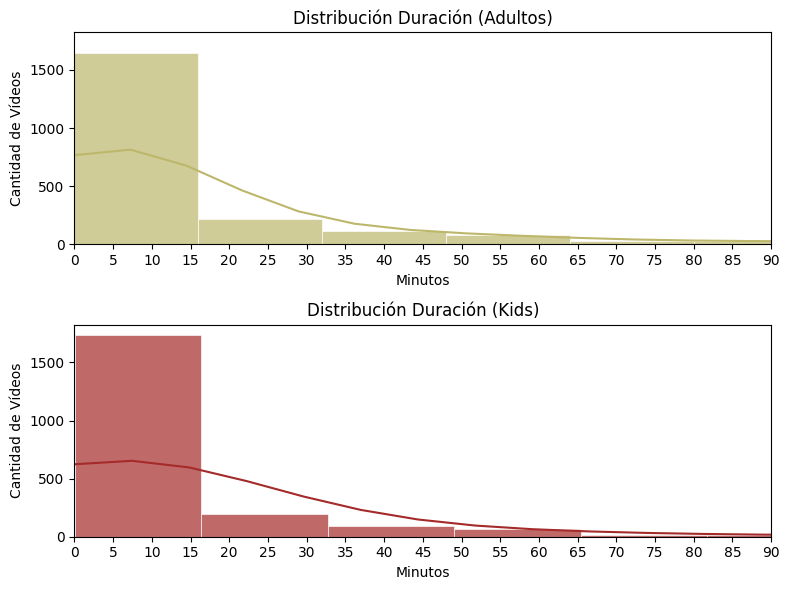

In [5]:

# Configuración
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharey=True)

utils.graficar_histograma_duracion(df_Adult, 'Distribución Duración (Adultos)', ax[0], 'darkkhaki')
utils.graficar_histograma_duracion(df_Kids, 'Distribución Duración (Kids)', ax[1], 'brown')

plt.tight_layout()
plt.show()

Kids: La distribución extremadamente concentrada en duraciones muy cortas (generalmente entre 0 y 15 minutos). Se puede observar qeu apenas hay videos de más de 15 minutos, lo que indica que el contenido infantil está diseñado para captar la atención de forma rápida y breve.

Adultos: Aunque también tiene un pico en duraciones cortas, hay más variedad. Desde vídeos cortos informativos (de entre 0-15 minutos) hasta contenidos más extensos que el público adulto es capaz de retener.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_30928\4239985363.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')


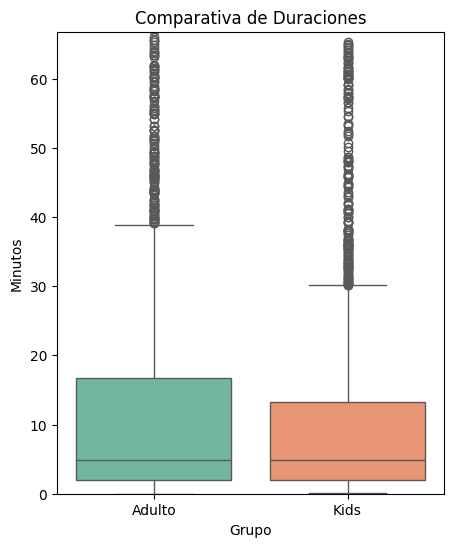

In [6]:
df_total = pd.concat([
    df_Adult.assign(Grupo='Adulto'),
    df_Kids.assign(Grupo='Kids')
])

plt.figure(figsize=(5, 6))
sns.boxplot(x='Grupo', y='Duracion', data=df_total, palette='Set2')     

# zoom para que se vea mejor
limite_superior = df_total['Duracion'].quantile(0.95) * 0.7 
plt.ylim(0, limite_superior) 

plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.show()

Como se puede observar la mediana es prácticamente igual para adultos que para niños. Esto sugiere que hay un tiempo ideal para mantener la atención antes de que el usuario pase al siguiente vídeo, independientemente de su edad. Se puede estimar que este valor está entre 4 y 7 minutos.

La caja del grupo de adultos es más alta. Hay un mayor rango intercuartílico, lo que significa que no hay una duración estándar tan rígida como en los niños. Los adultos consumen una gama de tiempos mucho más amplia.

En ambos grupos vemos puntos por encima de los bigotes (outliers), pero en adultos estos valores extremos suelen llegar a duraciones mucho mayores, mientras que en niños, incluso los vídeos que se consideran más largos siguen teniendo una duración razonable.

# Top 10 géneros

c:\Users\Usuario\Documents\U SEGUNDO AÑO\SEGUNDO CUATRI\PD1\c2526-R1\src\analisisutils.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette=paleta, ax=ax_obj)
c:\Users\Usuario\Documents\U SEGUNDO AÑO\SEGUNDO CUATRI\PD1\c2526-R1\src\analisisutils.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette=paleta, ax=ax_obj)


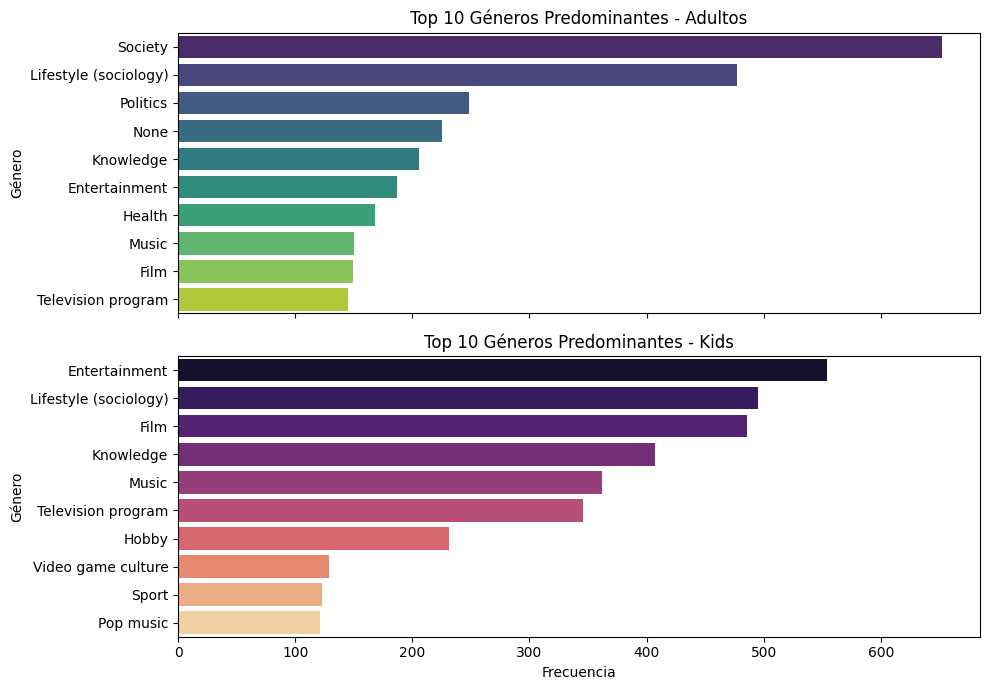

In [7]:
# Configuración
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Llamamos a la función para cada grupo
utils.graficar_top_generos(df_Adult, 'Top 10 Géneros Predominantes - Adultos', ax[0], 'viridis')
utils.graficar_top_generos(df_Kids, 'Top 10 Géneros Predominantes - Kids', ax[1], 'magma')

plt.tight_layout()
plt.show()

El perfil del público adulto destaca por su alta fragmentación y heterogeneidad temática. Conviven dos vertientes claras: por un lado, una fuerte inclinación hacia contenidos informativos y de actualidad ('Society', 'Politics', 'Knowledge') y, por otro, un consumo de ocio más tradicional ('Music', 'Film'). 

En cuanto al público infantil, se observa una polarización extrema. El contenido se agrupa casi exclusivamente en 'Entertainment' y 'Music', lo que define un patrón de consumo principalmente lúdico. A diferencia del equilibrio observado en los primeros 5 puestos del ranking adulto, en el segmento Kids los dos primeros generos acaparan el volumen total. 

Finalmente, la presencia significativa de vídeos no clasificados ('None') en ambos grupos representa un hallazgo crítico para la fase de modelado. Esto sugiere la existencia de contenidos híbridos que no encajan en las etiquetas predefinidas de la plataforma, lo que plantea el reto de refinar la limpieza de datos o considerar estas instancias como una categoría de "contenido inclasificable".

# Densidad de habla (wpm)

In [8]:
#Agregamos una nueva columna a todos los df
df_Adult['Palabras_Por_Minuto'] = df_Adult.apply(utils.calcular_wpm, axis=1)
df_Adult['Palabras_Por_Minuto'] = round(df_Adult['Palabras_Por_Minuto'], 2)

df_Kids['Palabras_Por_Minuto'] = df_Kids.apply(utils.calcular_wpm, axis=1)
df_Kids['Palabras_Por_Minuto'] = round(df_Kids['Palabras_Por_Minuto'], 2)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_30928\3005112938.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')


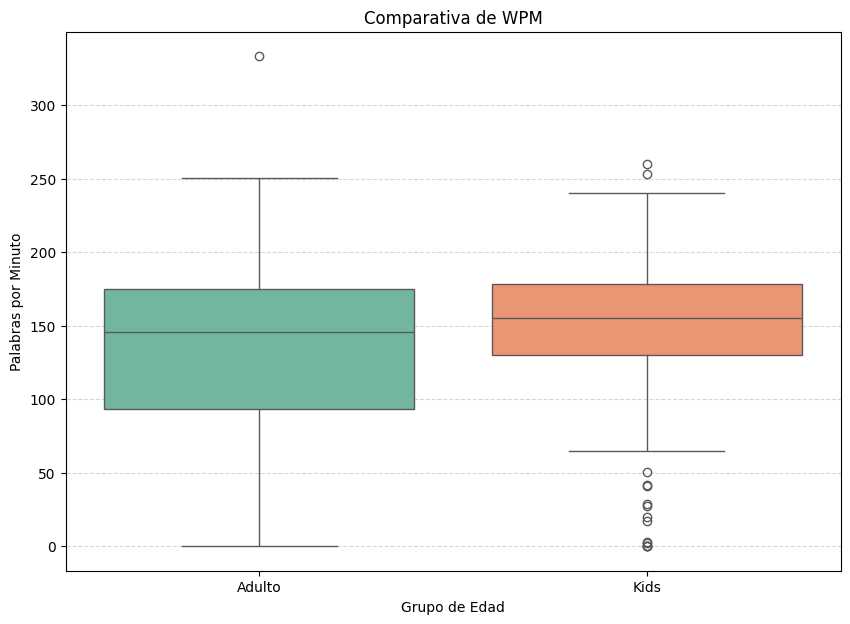

In [10]:
# Filtramos los vídeos sin palabras que no tienen subtitulos
df_wpm_total = pd.concat([
    df_Adult[df_Adult['Palabras_Por_Minuto'] > 0].assign(Grupo='Adulto'),
    df_Kids[df_Kids['Palabras_Por_Minuto'] > 0].assign(Grupo='Kids')
])

#Gráfica
plt.figure(figsize=(10, 7))

sns.boxplot(x='Grupo', y='Palabras_Por_Minuto', data=df_wpm_total, palette='Set2')

plt.title('Comparativa de WPM')
plt.xlabel('Grupo de Edad')
plt.ylabel('Palabras por Minuto')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Sorprendentemente, la mediana de palabras por minuto en el grupo Kids es ligeramente superior a la del grupo Adulto. Esto sugiere que, cuando un vídeo infantil es de carácter narrativo o educativo, mantiene un ritmo verbal constante y dinámico para mantener la atención del menor.

La caja del grupo infantil es notablemente más compacta. Esto indica que el contenido para niños sigue un estándar de producción muy rígido: el ritmo de habla está calibrado para ser uniforme, evitando tanto los silencios prolongados como las ráfagas de palabras ininteligibles.

El grupo Adulto presenta una caja mucho más amplia y bigotes más largos. Esto refleja la enorme heterogeneidad de su contenido; mientras que en Kids el ritmo es predecible, en adultos conviven géneros con una carga de guion mínima junto a otros de altísima densidad verbal.

Para nuestro clasificador, esto significa que el WPM por sí solo no define si un vídeo es para niños o adultos, sino su variabilidad.

Es importante señalar que la muestra de vídeos infantiles con subtítulos disponibles es considerablemente menor que la de adultos. Esto suguiere que los resultados de WPM en el grupo Kids podrían no ser plenamente representativos.

# Keywords 

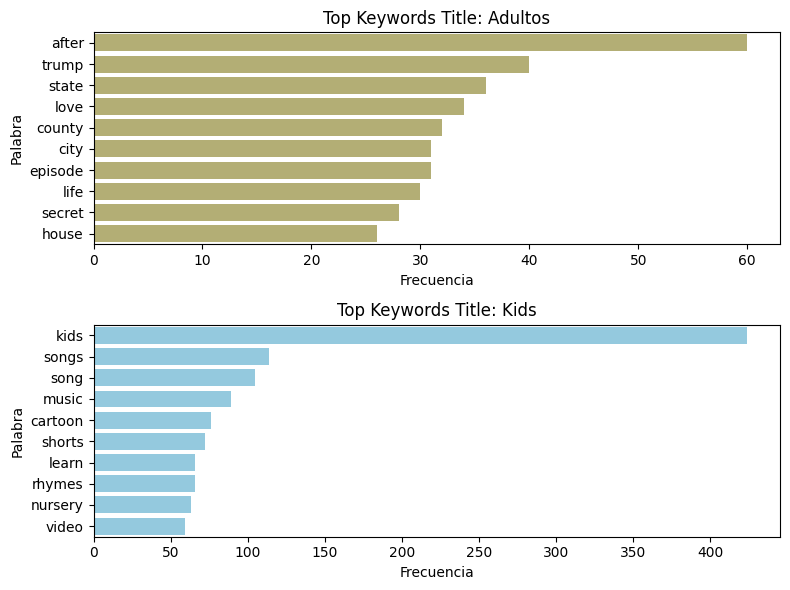

In [11]:
#Palabras más comunes en títulos
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

utils.graficar_palabras_comunes(df_Adult, 'Titulo', 'Top Keywords Title: Adultos', ax[0], 'darkkhaki')
utils.graficar_palabras_comunes(df_Kids, 'Titulo', 'Top Keywords Title: Kids', ax[1], 'skyblue')

plt.tight_layout()
plt.show()

Se puede observar que los titulos de los videos adultos tienen un enfoque más informativo. Las palabras clave como 'Trailer', 'News', 'Trump', 'Official' y 'War' confirman un consumo basado en la actualidad política y el cine. Los títulos son descriptivos y parece que buscan informar sobre un contenido específico.

Por otro lado los titulos de los videos infantiles aparentan ser mas genéricos. Los términos predominantes son 'Kids', 'cartoon', 'Song', 'nursery'. Esto refuerza la idea de un consumo lúdico donde se busca el entretenimiento directo.

En el grupo Kids, el uso de la palabra 'kids' es masivo. Esto indica que el modelo de predicción de éxito para niños debería dar mucho peso a esta palabra, ya que define el producto de forma casi inequívoca.

En el grupo Adulto, vemos palabras como 'new' y 'day', lo que sugiere que el usuario adulto valora la actualidad del contenido.


**SUBTITULOS**

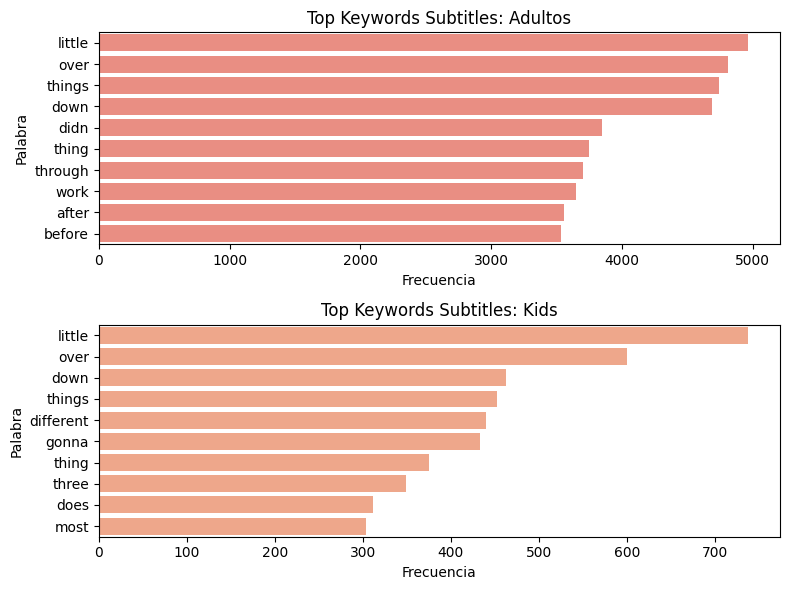

In [12]:
#Palabras mas comunes en subtítulos
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

utils.graficar_palabras_comunes(df_Adult, 'Subtitulos', 'Top Keywords Subtitles: Adultos', ax[0], 'salmon')
utils.graficar_palabras_comunes(df_Kids, 'Subtitulos', 'Top Keywords Subtitles: Kids', ax[1], 'lightsalmon')

plt.tight_layout()
plt.show()